### L = 3

Possible configurations: $ |\sigma\sigma\sigma\rangle, |\sigma\mu\sigma\rangle, |\mu\sigma\mu\rangle, |\mu\mu\mu\rangle $

In [1]:
import numpy as np
from numpy.linalg import eigh

In [51]:
def ising_fusCat_hamiltonian(r, theta):

    H = np.zeros(shape=(15, 15))

    # Elements
    H[0, 1:7] = -np.cos(theta)/np.sqrt(2)
    H[1:7, 0] = -np.cos(theta)/np.sqrt(2)
    for i in range(1, 13):
        H[i, i] = -2*r

    # The sin's
    H[7, 1] = H[7, 3] = -np.sin(theta)
    H[1, 7] = H[3, 7] = -np.sin(theta)

    H[8, 2] = H[8, 4] = -np.sin(theta)
    H[2, 8] = H[4, 8] = -np.sin(theta)

    H[9, 1] = H[9, 5] = -np.sin(theta)
    H[1, 9] = H[5, 9] = -np.sin(theta)

    H[10, 2] = H[10, 6] = -np.sin(theta)
    H[2, 10] = H[6, 10] = -np.sin(theta)

    H[11, 3] = H[11, 5] = -np.sin(theta)
    H[3, 11] = H[5, 11] = -np.sin(theta)

    H[12, 4] = H[12, 6] = -np.sin(theta)
    H[4, 12] = H[6, 12] = -np.sin(theta)

    # The cos's
    H[13, 7] = H[13, 9] = H[13, 11] = -np.cos(theta)
    H[7, 13] = H[9, 13] = H[11, 13] = -np.cos(theta)

    H[14, 8] = H[14, 10] = H[14, 12] = -np.cos(theta)
    H[8, 14] = H[10, 14] = H[12, 14] = -np.cos(theta)

    return H

In [52]:
H = ising_fusCat_hamiltonian(r=0, theta=np.pi/4)
energies, eigenvectors = eigh(H)

In [53]:
sorted_index = np.argsort(energies)
abs_tol = 0.0001

energy_deg_list = []
for index in sorted_index:
    if index == 0:
        energy_deg_list.append({"Energy": energies[0], "Degeneracy": 1})

    elif abs(energies[index] - energy_deg_list[-1]["Energy"]) < abs_tol:
        energy_deg_list[-1]["Degeneracy"] += 1

    else:
        energy_deg_list.append({"Energy": energies[index], "Degeneracy": 1})
        
energy_deg_list

[{'Energy': np.float64(-2.121320343559643), 'Degeneracy': 1},
 {'Energy': np.float64(-1.8708286933869716), 'Degeneracy': 1},
 {'Energy': np.float64(-0.7071067811865495), 'Degeneracy': 5},
 {'Energy': np.float64(-8.120310312446905e-17), 'Degeneracy': 1},
 {'Energy': np.float64(0.7071067811865462), 'Degeneracy': 5},
 {'Energy': np.float64(1.8708286933869704), 'Degeneracy': 1},
 {'Energy': np.float64(2.121320343559645), 'Degeneracy': 1}]

# AI generated

In [2]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

# Constants for simple objects
I, PSI, SIGMA = 0, 1, 2

def is_valid_state(state):
    """Filter states based on the Z_2 grading constraint."""
    for i in range(len(state)):
        left, right = state[i], state[(i + 1) % len(state)]
        if (left == I and right == PSI) or (left == PSI and right == I):
            return False
    return True

def generate_representatives(L, k):
    """Generate orbit representatives and valid states for a specific momentum sector."""
    all_states = [np.array(list(np.base_repr(i, base=3).zfill(L)), dtype=int) for i in range(3**L)]
    valid_states = [s for s in all_states if is_valid_state(s)]
    
    visited = set()
    reps = []
    
    for state in valid_states:
        state_tuple = tuple(state)
        if state_tuple not in visited:
            orbit = [tuple(np.roll(state, shift)) for shift in range(L)]
            rep = min(orbit)
            periodicity = len(set(orbit))
            
            # Check for destructive interference in this k-sector
            if (k * periodicity) % (2 * np.pi) == 0:
                reps.append({'rep': rep, 'R': periodicity})
                
            visited.update(orbit)
            
    return reps

def find_representative_and_shift(state):
    """
    Returns the orbit representative and the number of left shifts 
    required to reach it from the original state.
    """
    L = len(state)
    orbit = [tuple(np.roll(state, shift)) for shift in range(L)]
    rep = min(orbit)
    shift_j = orbit.index(rep)
    return rep, shift_j

def solve_spectrum(L, r, theta, num_eigenvalues=5):
    """Solve lowest eigenvalues for all momentum sectors."""
    spectra = {}
    for m in range(L):
        k = 2 * np.pi * m / L
        reps = generate_representatives(L, k)
        
        if not reps:
            continue
            
        H_k = build_hamiltonian_block(L, k, reps, r, theta)
        
        if H_k.shape[0] > num_eigenvalues:
            evals, _ = eigsh(H_k, k=num_eigenvalues, which='SA')
        else:
            evals = np.linalg.eigvalsh(H_k.toarray())
            
        spectra[k] = evals
    return spectra

In [3]:
def is_mu(x):
    """Helper to identify if a site is in the vacuum sector {I, psi} -> {0, 1}"""
    return x in (0, 1)

def is_sigma(x):
    """Helper to identify if a site is an anyon {sigma} -> {2}"""
    return x == 2

def build_hamiltonian_block(L, k, reps, r, theta):
    """
    Constructs the Hamiltonian matrix for a specific momentum sector k.
    State representation: 0 = I, 1 = psi, 2 = sigma
    """
    dim = len(reps)
    H_k = lil_matrix((dim, dim), dtype=complex)
    rep_to_idx = {reps[idx]['rep']: idx for idx in range(dim)}
    
    # Outer loop: Iterate over all representative states in this k-sector
    for i, state_data in enumerate(reps):
        rep = state_data['rep']
        R_a = state_data['R']
        
        # Inner loop: Iterate over every lattice site j to apply local H_i
        for j in range(L):
            left = rep[(j - 1) % L]
            mid = rep[j]
            right = rep[(j + 1) % L]
            
            # ==========================================
            # 1. H_dw Evaluation (Equation 14)
            # ==========================================
            val_dw = 0.0
            
            if is_mu(left) and is_mu(mid) and is_sigma(right): val_dw = r
            elif is_sigma(left) and is_mu(mid) and is_mu(right): val_dw = r
            elif is_mu(left) and is_sigma(mid) and is_sigma(right): val_dw = r
            elif is_sigma(left) and is_sigma(mid) and is_mu(right): val_dw = r
            
            # Apply overall negative sign to the diagonal element
            H_k[i, i] -= val_dw 
            
            # ==========================================
            # 2. H_flip Evaluation (Equation 15)
            # ==========================================
            transitions = []
            
            # |mu, mu, mu> -> cos(theta) |mu, sigma, mu>
            if is_mu(left) and is_mu(mid) and is_mu(right):
                transitions.append((2, np.cos(theta)))
                
            # |mu, mu, sigma> -> sin(theta) |mu, sigma, sigma>
            elif is_mu(left) and is_mu(mid) and is_sigma(right):
                transitions.append((2, np.sin(theta)))
                
            # |mu, sigma, nu> -> delta_{mu,nu} cos(theta) |mu, mu, mu>
            elif is_mu(left) and is_sigma(mid) and is_mu(right):
                if left == right: # Enforces the Kronecker delta
                    transitions.append((left, np.cos(theta)))
                    
            # |sigma, mu, mu> -> sin(theta) |sigma, sigma, mu>
            elif is_sigma(left) and is_mu(mid) and is_mu(right):
                transitions.append((2, np.sin(theta)))
                
            # |mu, sigma, sigma> -> sin(theta) |mu, mu, sigma>
            elif is_mu(left) and is_sigma(mid) and is_sigma(right):
                transitions.append((left, np.sin(theta)))
                
            # |sigma, mu, sigma> -> [cos(theta)/sqrt(2)] |sigma, sigma, sigma>
            elif is_sigma(left) and is_mu(mid) and is_sigma(right):
                transitions.append((2, np.cos(theta) / np.sqrt(2)))
                
            # |sigma, sigma, mu> -> sin(theta) |sigma, mu, mu>
            elif is_sigma(left) and is_sigma(mid) and is_mu(right):
                transitions.append((right, np.sin(theta)))
                
            # |sigma, sigma, sigma> -> [cos(theta)/sqrt(2)] ( |sigma, 0, sigma> + |sigma, 1, sigma> )
            elif is_sigma(left) and is_sigma(mid) and is_sigma(right):
                amp = np.cos(theta) / np.sqrt(2)
                transitions.extend([(0, amp), (1, amp)])
                
            # Process all valid off-diagonal transitions
            for new_mid, amp in transitions:
                new_state = list(rep)
                new_state[j] = new_mid
                
                # Verify the Z_2 grading constraint isn't violated
                if is_valid_state(new_state):
                    new_rep, shift_j = find_representative_and_shift(new_state)
                    
                    if new_rep in rep_to_idx:
                        b_idx = rep_to_idx[new_rep]
                        R_b = reps[b_idx]['R']
                        
                        # Apply overall negative sign, transition amplitude, and momentum phase factor
                        matrix_element = -amp * np.sqrt(R_a / R_b) * np.exp(1j * k * shift_j)
                        H_k[b_idx, i] += matrix_element

    return H_k.tocsr()

In [5]:
solve_spectrum(L=10, r=20, theta=np.pi/4, num_eigenvalues=10)

KeyboardInterrupt: 

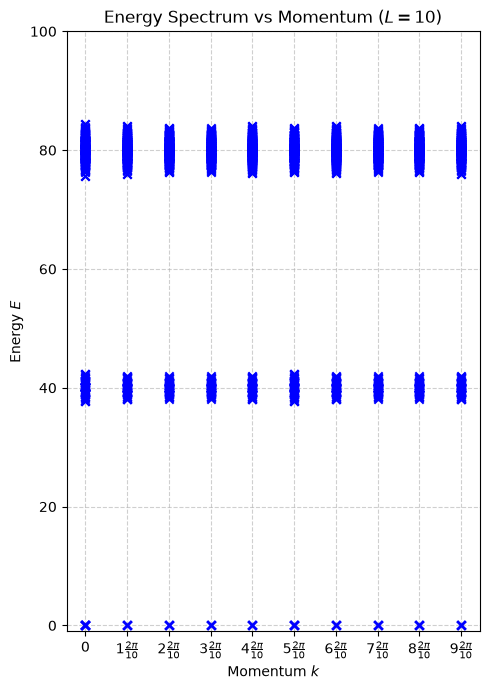

In [ ]:
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import numpy as np

# Parameters
L = 10
r = -20
theta = np.pi / 4

# Momentum values
ks = np.array([n * (2 * np.pi / L) for n in range(L)])
E_list = []

# Diagonalize block-by-block
for k in ks:
    reps = generate_representatives(L=L, k=k)
    H_block = build_hamiltonian_block(L=L, k=k, reps=reps, r=r, theta=theta)
    
    # energies, states = eigsh(H_block, k=10) # eigsh
    energies = np.linalg.eigvalsh(H_block.toarray())
    E_list.append(energies)

# Plot all energy levels against momentum k
plt.figure(figsize=(5, 7))

for idx, k in enumerate(ks):
    # Scatter plot all eigenvalues for each k sector
    plt.scatter([k] * len(E_list[idx]), E_list[idx] - min(E_list[idx]), color='blue', zorder=3, marker='x') # reset reference level

# plt.ylim([-6, -2]) # r = 0, theta = pi/4
plt.ylim([-1, 100])
plt.xlabel(r'Momentum $k$')
plt.ylabel('Energy $E$')
plt.title(f'Energy Spectrum vs Momentum ($L={L}$)')
plt.xticks(ks, [f"${n}$" if n > 0 else "0" for n in range(L)])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

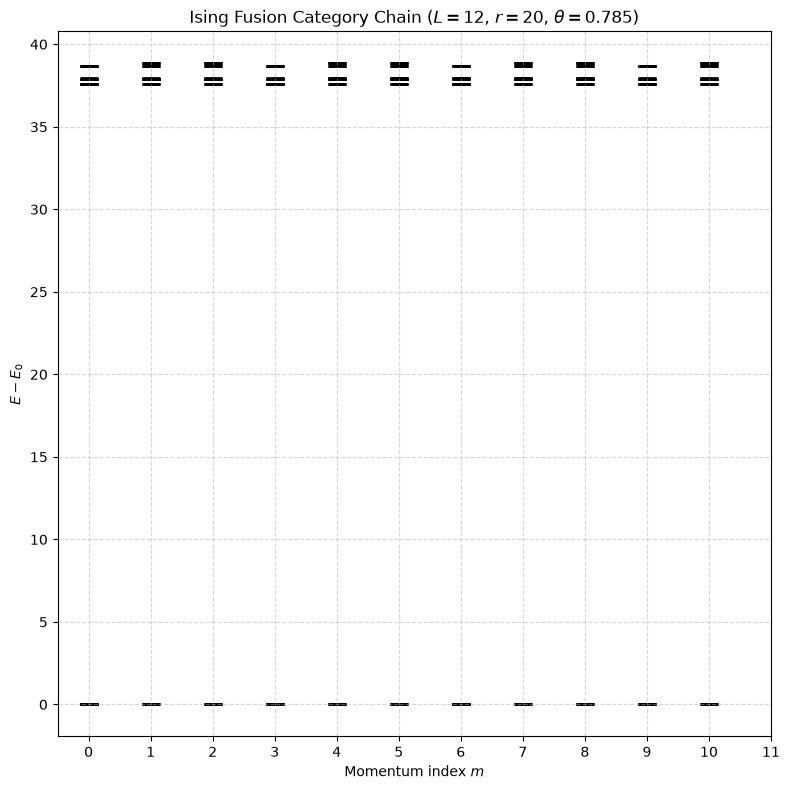

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_shifted_spectrum(L, r, theta, num_eigenvalues=5):
    """
    Solves the Hamiltonian for all momentum sectors, shifts the 
    ground state to E=0, and plots the spectrum against momentum index m.
    """
    # 1. Obtain the raw spectrum using the previously defined function
    spectra = solve_spectrum(L, r, theta, num_eigenvalues)
    
    # 2. Find the global ground state energy (E_0) across all k-sectors
    global_min = float('inf')
    for evals in spectra.values():
        if len(evals) > 0:
            sector_min = np.min(evals)
            if sector_min < global_min:
                global_min = sector_min
                
    # 3. Initialize the plot
    plt.figure(figsize=(8, 8))
    
    # 4. Process and plot each momentum sector
    for m in range(L):
        k = 2 * np.pi * m / L
        
        # Check if this momentum sector has valid states
        if k in spectra and len(spectra[k]) > 0:
            # Shift the spectrum
            shifted_evals = spectra[k] - global_min
            
            # Plot the eigenvalues as horizontal energy levels
            plt.scatter([m] * len(shifted_evals), shifted_evals, 
                        color='black', marker='_', s=150, linewidth=2)

    # 5. Formatting
    plt.xlabel('Momentum index $m$')
    plt.ylabel('$E - E_0$')
    plt.title(f'Ising Fusion Category Chain ($L={L}$, $r={r}$, $\\theta={theta:.3f}$)')
    plt.xticks(range(L))
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Ensure the y-axis starts exactly at 0 with a small top margin
    y_max = plt.gca().get_ylim()[1]
    y_min = plt.gca().get_ylim()[0]
    plt.ylim([y_min, y_max])
    # plt.ylim(-0.0001, 0.0004) # r=20, theta=pi/4, L=8
    # plt.ylim(-0.011, 0.105) # r=-20, theta=pi/4
    
    plt.tight_layout()
    plt.show()

# Example execution for a small system:
plot_shifted_spectrum(L=12, r=20, theta=np.pi/4, num_eigenvalues=15)

In [174]:
# np.roll (a: np.array, shift: integer, axis: None)
# If shift > 0, then shift to the right, if shift < 0, then to the left

example_array = [1, 2, 3, 4, 5]
np.roll(example_array, -1)

# np.base_repr (number: integer, base: integer, padding: 0)
# input a number and returns a string
# padding is the number of zeros you want to add to the left of the string

np.base_repr(number=2, base=2, padding=1)
np.base_repr(number=10, base=3, padding=0)

# .zfill (L: integer)
# a build-in python method for padding zeros until a length L is reached

np.base_repr(number=10, base=3, padding=0).zfill(10)

'0000000101'

In [175]:
# E.g. L = 3
# The possible values of k = 0, 2pi/3, 4pi/3

L = 3
reps_dict = {}

for k in [0, 2*np.pi/3, 4*np.pi/3]:
    rep = generate_representatives(L, k)
    reps_dict[f"k = {k:.2f}"] = rep

reps_dict

{'k = 0.00': [{'rep': (np.int64(0), np.int64(0), np.int64(0)), 'R': 1},
  {'rep': (np.int64(0), np.int64(0), np.int64(2)), 'R': 3},
  {'rep': (np.int64(0), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(1), np.int64(1)), 'R': 1},
  {'rep': (np.int64(1), np.int64(1), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(2), np.int64(2), np.int64(2)), 'R': 1}],
 'k = 2.09': [{'rep': (np.int64(0), np.int64(0), np.int64(2)), 'R': 3},
  {'rep': (np.int64(0), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(1), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(2), np.int64(2)), 'R': 3}],
 'k = 4.19': [{'rep': (np.int64(0), np.int64(0), np.int64(2)), 'R': 3},
  {'rep': (np.int64(0), np.int64(2), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(1), np.int64(2)), 'R': 3},
  {'rep': (np.int64(1), np.int64(2), np.int64(2)), 'R': 3}]}

# Audit of the Ising fusion-category ED implementation

Reference: Soumil Roychowdhury and Chenjie Wang, *Symmetry breaking phases and transitions in an Ising fusion category lattice model*, supplied manuscript dated September 9, 2026. Page references below refer to its printed page numbers. Numerical conventions: `I=0`, `PSI=1`, `SIGMA=2`, lattice spacing one, physical momentum `q=2*pi*m/L`.

## Main finding

The submitted code implements the constrained Hilbert space and microscopic Hamiltonian in Eqs. (7)–(15) correctly. Its momentum phase and orbit-length normalization are mutually consistent. Two reproducible computational bugs require correction: floating-point momentum compatibility and the complex-ARPACK boundary case. Several expectations about finite-size spectra and plotting also require correction. The repair must not invent changes to the already correct local matrix elements.

The original snippet contains escaped underscores, mixed Markdown fences, and missing indentation. The benchmark runner repairs this presentation damage before executing the algorithm. It otherwise preserves the supplied representative selection, local branches, phases, and normalization. For the small before/after comparisons it diagonalizes the complete original and repaired blocks densely, avoiding iterative solver selection effects.

## Findings by category

| Category | Finding | Action |
|---|---|---|
| Numerical precision, demonstrated bug | `(k*R) % (2*pi) == 0` can reject allowed orbits, even every orbit in a sector. | Pass integer `m`; require `(m*R) % L == 0`. |
| Solver logic, demonstrated bug | Complex `eigsh` uses `eigs`; the condition `dim > nev` admits the unsupported `nev=dim-1` case. | Use dense Hermitian diagonalization when `dim <= nev+1`, with an explicit memory guard. |
| Documentation | `np.roll(state,+s)` is a right shift, although the docstring says left. | State the translation and momentum-eigenvalue convention explicitly. |
| Physics interpretation | Figure 3's horizontal coordinate is integer momentum `m`, despite being labeled `k`. | Plot `m`, or convert the paper's tick positions to radians. |
| Physics interpretation | Raw energies are not scaling dimensions. | Subtract the common ground energy and determine a velocity/energy scale; use the paper's stress-tensor normalization at `r=0`. |
| Physics interpretation | `r=+20` tests CatAFM, not CatFM. | Include `r=-20` for the CatFM test. |
| Physics interpretation | Exact threefold/fourfold degeneracy and clean conformal towers are not tiny-ring requirements. | Study splitting versus size, distinguish the effective chain length, and use commensurate CatAFM rings. |
| Missing diagnostic, not Hamiltonian error | The original code does not construct Eqs. (17)–(21), so it cannot color states by categorical charge. | Construct `U(psi)` and `U(sigma)` for validation/classification. Do not multiply them into `H`. |
| Performance | Rebuilds and stores all `3**L` states in each momentum sector; repeats orbit searches after every transition. | Prune forbidden adjacencies during generation, build orbits once, and cache representative lookups. |
| Robustness | No matrix Hermiticity, projection completeness, or eigenpair residual checks. | Add meaningful checks. Never conceal an assembly error by replacing `H` with `(H+H.dagger)/2`. |

Explicit sorting is a useful guarantee, but it is not classified as a demonstrated original bug: the submitted `eigsh` call requests eigenvectors, whose associated values are already returned in algebraic order for this mode.

## Statement-by-statement audit

| Original statement/block | Verdict and reason |
|---|---|
| `I, PSI, SIGMA = 0,1,2` | Correct object encoding. These are horizontal fusion-tree labels `x_i`, not the external `a_i`. |
| Loop through `range(len(state))` with neighbor `(i+1)%L` | Correct; includes the periodic seam. |
| Reject adjacent `(I,PSI)` and `(PSI,I)` | Exactly the paper's constrained basis, for valid object labels. A reusable public validator should additionally reject invalid labels/lengths. |
| Enumerate base-three strings and filter | Mathematically complete; severe avoidable time and memory cost. |
| `orbit = [tuple(np.roll(state,shift)) ...]` | Correct ordinary lattice translation orbit. No `F` move is necessary for cyclically relabeling this periodic basis. |
| `rep=min(orbit)` | Correct canonical representative; any consistent representative choice would work. |
| `periodicity=len(set(orbit))` | Correct number of distinct translates and minimal positive period `R`. |
| Floating-point modulo compatibility test | Incorrect; replace with integer arithmetic. |
| `visited.update(orbit)` even when incompatible | Correct. All members belong to the same forbidden orbit in that momentum sector. |
| `find_representative_and_shift` | Implementation correct; shift is a right shift from target to representative, not representative to target. Correct its docstring. |
| Momentum loop `m=0,...,L-1`, `k=2*pi*m/L` | Correct physical momenta. Keep `m` as the primary sector identifier. |
| Skip an empty sector | Correct only if sector emptiness is computed correctly. The modulo bug can make this silently discard real states. |
| `eigsh(...,which='SA')` | Correct target: lowest algebraic energies. Fix its boundary condition and check convergence/residuals. |
| Dense `eigvalsh` branch | Correct for a verified Hermitian matrix. A Hermitian solver alone does not verify Hermiticity. |
| `is_mu` calls `{I,psi}` a vacuum sector | Membership test correct; wording should say even-grade sector `C_+`. Only `I` is the vacuum object. |
| `is_sigma` calls only sigma an anyon | Membership test correct; wording is imprecise because the paper also calls the other simple objects anyons. |
| `lil_matrix(...,dtype=complex)` | Correct representation; COO accumulation followed by CSR is more suitable for many additive entries. |
| Loop over all sites of each representative | Correct. Translation projection accounts for the other configurations in its orbit. |
| Read `left,mid,right` using periodic indices | Correct for three distinct sites; the delivered API requires `L>=3`. |
| Four nonzero `val_dw=r` branches | Exactly Eq. (14); the other four types have zero diagonal contribution. |
| `H_k[i,i] -= val_dw` | Correct sign from Eqs. (12)–(13). |
| Eight flip branches | All correct; detailed table follows. |
| Validate the new configuration | Correct defensive check. Valid inputs and the listed transitions already preserve the basis. |
| Drop a target whose representative is absent from the sector | Correct: its projection into this sector vanishes. |
| `sqrt(R_a/R_b)` | Correct normalization, with `R` defined as the number of distinct translates. |
| `exp(+1j*k*shift_j)` | Correct for the convention derived below. |
| `-amp` | Correct global Hamiltonian sign. |
| `H_k[b_idx,i] += matrix_element` | Correct target-row/source-column convention. Addition is required when distinct sites or paths hit the same matrix entry. |

### Basis proof: Eqs. (7)–(10), pp. 3–4

If neighboring horizontal labels have the same grade, Eq. (8) fixes their connecting external object to `I`. Fusion with `I` requires the horizontal labels to agree. Thus `I-psi` and `psi-I` are forbidden; `I-I`, `psi-psi`, and `sigma-sigma` are allowed. If their grades differ, the external object is uniquely `sigma`, and either `I-sigma` or `psi-sigma` (in either order) is allowed. All applicable fusion multiplicities are one. Consequently there is no missing independent fusion label once these pair constraints hold, including at the periodic seam. Merely checking Eq. (7)'s grading without Eq. (8) would not suffice; the submitted forbidden-pair check incorporates both.

An independent basis count is

\[
A=\begin{pmatrix}1&0&1\\0&1&1\\1&1&1\end{pmatrix},\qquad
D_L=\operatorname{Tr}(A^L)=1+(1+\sqrt2)^L+(1-\sqrt2)^L.
\]

Use an integer recurrence to evaluate this formula, avoiding another floating-point counting operation. It gives `D_4=35`, `D_6=199`, `D_8=1155`, and `D_12=39203`. The dimensions of all momentum sectors must sum to `D_L`.

### Every local matrix element: Eqs. (12)–(15), p. 4

Here `mu,nu` independently mean `I` or `psi`; repeated `mu` labels mean the same object. Write `c=cos(theta)` and `s=sin(theta)`. This table gives the paper's **positive local operators**; the full Hamiltonian includes their overall minus sign.

| Input | `H_dw` diagonal | `H_flip` output |
|---|---:|---|
| `mu mu mu` | 0 | `c \|mu sigma mu>` |
| `mu mu sigma` | `r` | `s \|mu sigma sigma>` |
| `mu sigma nu` | 0 | `delta_mu,nu c \|mu mu mu>` |
| `sigma mu mu` | `r` | `s \|sigma sigma mu>` |
| `mu sigma sigma` | `r` | `s \|mu mu sigma>` |
| `sigma mu sigma` | 0 | `(c/sqrt(2)) \|sigma sigma sigma>` |
| `sigma sigma mu` | `r` | `s \|sigma mu mu>` |
| `sigma sigma sigma` | 0 | `(c/sqrt(2)) (\|sigma I sigma> + \|sigma psi sigma>)` |

Both branches out of `sigma sigma sigma` have amplitude `c/sqrt(2)`, not `c/2`, `c`, or an extra factor of `sqrt(2)`. Eq. (15) already contains the needed fusion recoupling factors. The original code matches every row.

For intuition, let `g_j=+1` on a `mu` site and `g_j=-1` on a `sigma` site. The diagonal energy is `-(r/2) sum_j (1-g_{j-1}g_{j+1})`. Positive `r` favors the four-site grade pattern `++--`; negative `r` favors equal grades at distance two. This also explains why the even-length negative-`r` classical manifold contains alternating configurations in addition to uniform ones.

### Translation phase and normalization

[NumPy's documented `roll`](https://numpy.org/doc/stable/reference/generated/numpy.roll.html) with shift `+1` implements

\[
T|x_0,x_1,\ldots,x_{L-1}\rangle=|x_{L-1},x_0,\ldots,x_{L-2}\rangle.
\]

Choose

\[
|a;m\rangle=\frac1{\sqrt{R_a}}\sum_{t=0}^{R_a-1} e^{iqt}T^t|a\rangle,
\qquad q=\frac{2\pi m}{L},\qquad T|a;m\rangle=e^{-iq}|a;m\rangle.
\]

The state exists iff `(m*R_a)%L==0`. For a local output `c`, the original finder returns `b=T^s c`. Therefore

\[
(H_m)_{ba}\mathrel{+}=h_{ca}\sqrt{\frac{R_a}{R_b}}e^{iqs}.
\]

One derivation uses `P_m=L^{-1} sum_t exp(iqt) T^t`: the normalized state is `sqrt(R_a) P_m|a>`, and `P_m|c>=exp(iqs)|b;m>/sqrt(R_b)`. This immediately yields the matrix element above. No quantum dimension belongs in this ordinary cyclic-group orbit normalization. For the alternative convention `T=e^{+iq}`, conjugate both the basis coefficients and the assembly phase. Changing the phase alone only exchanges the momentum labels `m` and `L-m` for this real Hamiltonian.

### Categorical symmetry: Eqs. (17)–(22), p. 5

Equations (17)–(21) define **global symmetry operators**, not additional terms in `H`. They are absent from the original code, so the code computes energies without the charge labels used to color Fig. 3.

`U(psi)` globally exchanges `I` and `psi`. `U(sigma)` exchanges the even- and odd-grade domains; for each original sigma domain, the new constant `mu'` label contributes the sign from its two bordering original `mu` labels in Eq. (20). With `n` such domains, each output has magnitude `2**(-n/2)`. The three uniform strings must be handled separately according to Eq. (21): `I -> sigma`, `psi -> sigma`, and `sigma -> I + psi`.

The delivered solver implements these operators and checks `Upsi^2=I`, `Usigma^2=I+Upsi`, `Upsi Usigma=Usigma`, Hermiticity, and commutation with `H`. Do not infer a categorical charge from an arbitrary eigenvector inside an exactly degenerate eigenspace: diagonalize the symmetry restricted to that eigenspace when labeling states.

### Eigensolver boundary bug

[SciPy documents that complex `eigsh` delegates to `eigs`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html). The delegated sparse routine requires the requested count to be less than `dim-1`. At `L=4`, `nev=6`, the original code calls it on the seven-dimensional `m=1,3` blocks and raises `TypeError: Cannot use scipy.linalg.eig for sparse A with k >= N - 1`. The original default `nev=5` happens not to trigger this case at `L=4,6`. The corrected solver handles it densely and reports nonconvergence rather than silently returning an incomplete spectrum.

## Interpreting Fig. 3

All three panels use `L=20` (p. 8). The paper's axis is the integer momentum index `m`; its phrase `k=2` for the stress tensor means physical momentum `4*pi/L`, not two radians.

At `r=0`, Eq. (25) gives gaps approaching `(2*pi*v/L) x`, with primary total dimensions `x=0,1/8,1`. The paper's normalization is

\[
x_n^{(L)}=\frac{2(E_n-E_0)}{E_{\min}(m=2)-E_0}.
\]

At very small `L`, the lowest `m=2` state need not be a clean stress-tensor state. Even when it is, finite-size corrections remain. The primary charges are `(Upsi,Usigma)=(1,+sqrt(2)),(-1,0),(1,-sqrt(2))`, respectively (p. 6).

CatFM is the **negative**-`r` regime. Its three vacua have `m=0`. For even rings, the additional alternating classical manifolds yield Ising-like excitations with the finite-size offset discussed in Eqs. (29)–(32); this offset is not the thermodynamic gap.

CatAFM is the **positive**-`r` regime. Its four-site patterns require `L` divisible by four; the manuscript explicitly treats other lengths as carrying a translation defect (p. 9). The four vacuum momentum centers are `m=0,L/4,L/2,3L/4`, with physical momenta `0,pi/2,pi,3pi/2`. The effective Ising chain has only `N=L/4` spins. Thus `L=4` has `N=1`, `L=6` is incommensurate, and even the paper's `L=20` has only `N=5` and strong finite-size effects. Four copies form a **direct sum**, not a tensor product with central charge two.

For any finite `r` at `theta=pi/4`, all allowed flip amplitudes are positive before the global minus sign. Every valid configuration can reach the all-sigma configuration through such flips. The full Hamiltonian therefore has a connected graph and nonpositive off-diagonal entries. Perron–Frobenius implies a unique exact finite-ring ground state. The threefold/fourfold statements describe asymptotic symmetry-breaking vacua and splittings that become tiny with size, not exact degeneracy that a tiny-ring test must enforce. Appendix B also explains that CatAFM sectors can mix at order `L/2`; at `L=4` this is already second order.

The CatAFM effective coupling magnitude is `J=sin(theta)^2 cos(theta)^2/(8*r^3)`. At `r=20,theta=pi/4`, `J=1/256000=3.90625e-6`, on top of an extensive energy near `-20L`. Use energy gaps, enough numerical precision, and residual checks to resolve this structure.

### A separate caveat about the manuscript

Eq. (37), also Eq. (B23), prints a positive coefficient multiplying the transverse Pauli flip for positive `r`. In the conventional spin basis identified in Eq. (35), the microscopic Eqs. (12)–(15) instead give a negative fourth-order flip coefficient. One virtual path converting a `mu mu` block to a `nu nu` block passes through `sigma mu`, `sigma sigma`, and `sigma nu`. Its amplitudes multiply to `sin(theta)^2 cos(theta)^2/2`, while the three denominators are `-2r,-4r,-2r`; it contributes `-sin(theta)^2 cos(theta)^2/(32r^3)`. The four ordering choices sum to `-J`. This suggests a missing minus sign in the printed effective Hamiltonian under the conventional Pauli convention. This observation is separate from the code audit and is not a reason to alter the explicitly specified microscopic Hamiltonian. Numerical benchmarks below use Eqs. (12)–(15) directly.

## Reproduction and scope

Requirements: Python 3.10 or later, NumPy, SciPy. The independent benchmark runner uses the same requirements. Run `python ising_fusion_ed.py --help` for the current CLI, and run `OPENBLAS_NUM_THREADS=1 python run_benchmarks.py` to regenerate the full audit data.

The solver is a validated sparse ED implementation with an explicit state-count resource guard, not a claim that Python tuples make the paper's `L=20` calculation inexpensive. There are `45,239,075` valid states at `L=20`, versus `3,486,784,401` unconstrained strings generated by the original approach. Scaling to that size needs substantial memory and generally compact state encoding, further symmetry reduction, or a matrix-free implementation. No `L=20` run was performed in this audit.

## Calculated results

The numerical tables and validation residuals below are generated from `benchmark_results.json` by the audit workflow. Full eigenvalue lists before and after are retained in that JSON; decimal displays are finite-precision ED results, not symbolic exact expressions.

<!-- GENERATED NUMERICAL RESULTS -->

### Before/after small-ring eigenvalues

All values below use `theta=pi/4`. The lowest five eigenvalues in **every** momentum sector are shown. Complete spectra, including all multiplicities, are in `benchmark_results.json`. Before and after columns agree to the printed precision; no physical matrix element has been changed.

#### L=4, r=0

| m | Dimension | Before (lowest five) | After (lowest five) |
|---:|---:|---|---|
| 0 | 12 | -2.776167642846, -2.594564659621, -1.514230239697, -0.876489718735, 0.000000000000 | -2.776167642846, -2.594564659621, -1.514230239697, -0.876489718735, 0.000000000000 |
| 1 | 7 | -1.510223959022, -1.414213562373, -0.468213192462, 0.000000000000, 0.468213192462 | -1.510223959022, -1.414213562373, -0.468213192462, 0.000000000000, 0.468213192462 |
| 2 | 9 | -1.306562964876, -1.224744871392, -0.541196100146, -0.000000000000, -0.000000000000 | -1.306562964876, -1.224744871392, -0.541196100146, -0.000000000000, -0.000000000000 |
| 3 | 7 | -1.510223959022, -1.414213562373, -0.468213192462, -0.000000000000, 0.468213192462 | -1.510223959022, -1.414213562373, -0.468213192462, -0.000000000000, 0.468213192462 |

#### L=4, r=20

| m | Dimension | Before (lowest five) | After (lowest five) |
|---:|---:|---|---|
| 0 | 12 | -80.099866216332, -80.099827433800, -40.057240418832, -40.038644355587, -39.992712771443 | -80.099866216332, -80.099827433800, -40.057240418832, -40.038644355587, -39.992712771443 |
| 1 | 7 | -80.049941545604, -80.049937655763, -40.007017917001, -40.000000000000, -39.955540538005 | -80.049941545604, -80.049937655763, -40.007017917001, -40.000000000000, -39.955540538005 |
| 2 | 9 | -80.000000000000, -80.000000000000, -40.042632231850, -40.037464909514, -40.007320990548 | -80.000000000000, -80.000000000000, -40.042632231850, -40.037464909514, -40.007320990548 |
| 3 | 7 | -80.049941545604, -80.049937655763, -40.007017917001, -40.000000000000, -39.955540538005 | -80.049941545604, -80.049937655763, -40.007017917001, -40.000000000000, -39.955540538005 |

#### L=4, r=-20

| m | Dimension | Before (lowest five) | After (lowest five) |
|---:|---:|---|---|
| 0 | 12 | -0.092578987775, -0.079569403240, -0.057240418832, -0.007847433171, 0.000000000000 | -0.092578987775, -0.079569403240, -0.057240418832, -0.007847433171, 0.000000000000 |
| 1 | 7 | -0.012500000610, 39.950062344237, 39.955540538005, 40.000000000000, 40.007017917001 | -0.012500000610, 39.950062344237, 39.955540538005, 40.000000000000, 40.007017917001 |
| 2 | 9 | -0.042632231850, -0.037464909514, -0.007320990548, 40.000000000000, 40.007320990548 | -0.042632231850, -0.037464909514, -0.007320990548, 40.000000000000, 40.007320990548 |
| 3 | 7 | -0.012500000610, 39.950062344237, 39.955540538005, 40.000000000000, 40.007017917001 | -0.012500000610, 39.950062344237, 39.955540538005, 40.000000000000, 40.007017917001 |

#### L=6, r=0

| m | Dimension | Before (lowest five) | After (lowest five) |
|---:|---:|---|---|
| 0 | 39 | -4.110638258398, -3.990984402238, -3.167227919772, -2.492009508166, -2.188616309225 | -4.110638258398, -3.990984402238, -3.167227919772, -2.492009508166, -2.188616309225 |
| 1 | 30 | -3.118893236997, -2.789191793248, -2.336145727760, -1.564187870027, -1.548072635920 | -3.118893236997, -2.789191793248, -2.336145727760, -1.564187870027, -1.548072635920 |
| 2 | 34 | -2.760211984927, -2.736910926616, -2.414327134342, -1.999512533427, -1.611807568080 | -2.760211984927, -2.736910926616, -2.414327134342, -1.999512533427, -1.611807568080 |
| 3 | 32 | -2.662792360131, -2.591713346515, -2.058215863049, -1.902113032590, -1.899691340403 | -2.662792360131, -2.591713346515, -2.058215863049, -1.902113032590, -1.899691340403 |
| 4 | 34 | -2.760211984927, -2.736910926616, -2.414327134342, -1.999512533427, -1.611807568080 | -2.760211984927, -2.736910926616, -2.414327134342, -1.999512533427, -1.611807568080 |
| 5 | 30 | -3.118893236997, -2.789191793249, -2.336145727760, -1.564187870027, -1.548072635920 | -3.118893236997, -2.789191793249, -2.336145727760, -1.564187870027, -1.548072635920 |

#### L=6, r=20

| m | Dimension | Before (lowest five) | After (lowest five) |
|---:|---:|---|---|
| 0 | 39 | -82.826414494227, -82.791386276167, -82.102774020901, -81.539568306048, -81.452019958495 | -82.826414494227, -82.791386276167, -82.102774020901, -81.539568306048, -81.452019958495 |
| 1 | 30 | -82.300564274478, -82.123184884293, -81.829200574949, -80.836288923274, -80.656445328911 | -82.300564274478, -82.123184884293, -81.829200574949, -80.836288923274, -80.656445328911 |
| 2 | 34 | -82.109676719638, -82.081286324543, -81.870280852530, -81.412164440736, -81.313570460483 | -82.109676719638, -82.081286324543, -81.870280852530, -81.412164440736, -81.313570460483 |
| 3 | 32 | -81.655647624953, -81.432382974425, -81.306562964876, -81.138806549643, -80.541196100146 | -81.655647624953, -81.432382974425, -81.306562964876, -81.138806549643, -80.541196100146 |
| 4 | 34 | -82.109676719638, -82.081286324543, -81.870280852530, -81.412164440736, -81.313570460483 | -82.109676719638, -82.081286324543, -81.870280852530, -81.412164440736, -81.313570460483 |
| 5 | 30 | -82.300564274478, -82.123184884293, -81.829200574949, -80.836288923274, -80.656445328911 | -82.300564274478, -82.123184884293, -81.829200574949, -80.836288923274, -80.656445328911 |

#### L=6, r=-20

| m | Dimension | Before (lowest five) | After (lowest five) |
|---:|---:|---|---|
| 0 | 39 | -0.075430828430, -0.075230844860, -0.075069772864, -0.062119313890, -0.058968572367 | -0.075430828430, -0.075230844860, -0.075069772864, -0.062119313890, -0.058968572367 |
| 1 | 30 | -0.037504397311, -0.024998856303, 38.973148751917, 39.258266417583, 39.258608222941 | -0.037504397311, -0.024998856303, 38.973148751917, 39.258266417583, 39.258608222941 |
| 2 | 34 | -0.037504358380, -0.024998858330, 38.986603605304, 39.256116718249, 39.258353033100 | -0.037504358380, -0.024998858330, 38.986603605304, 39.256116718249, 39.258353033100 |
| 3 | 32 | -0.062526967282, -0.059172252047, -0.037508255259, -0.015851987409, 38.588256189661 | -0.062526967282, -0.059172252047, -0.037508255259, -0.015851987409, 38.588256189661 |
| 4 | 34 | -0.037504358380, -0.024998858330, 38.986603605304, 39.256116718249, 39.258353033100 | -0.037504358380, -0.024998858330, 38.986603605304, 39.256116718249, 39.258353033100 |
| 5 | 30 | -0.037504397311, -0.024998856303, 38.973148751917, 39.258266417583, 39.258608222941 | -0.037504397311, -0.024998856303, 38.973148751917, 39.258266417583, 39.258608222941 |

### Explicit floating-point failure

For `L=12,m=11,R=12`, the floating remainder is `6.283185307179579` (nearly `2*pi`, not zero), whereas `(m*R)%L=0`. The original sector dimension is **0**; the corrected dimension is **3248**. This destroys momentum completeness and `m <-> L-m` symmetry in the original output.

At `r=0,theta=pi/4`, the restored `m=11` sector has lowest energies `-7.636536311207, -7.243133776051, -6.821088110020, -6.625045578336, -6.313195696929`. Before the fix, this sector has no reported eigenvalues.

### Ising primary convergence at r=0

Using the paper's stress-tensor normalization `x=2*(E-E0)/(E_min(m=2)-E0)`, the lowest three `m=0` states give:

| L | E0 | Spin gap | Energy-primary gap | x_spin | x_energy |
|---:|---:|---:|---:|---:|---:|
| 4 | -2.776167642846 | 0.181602983226 | 1.261937403149 | 0.247145353 | 1.717383487 |
| 6 | -4.110638258398 | 0.119653856161 | 0.943410338626 | 0.177209017 | 1.397203768 |
| 8 | -5.457593242400 | 0.089289987423 | 0.715955144237 | 0.145311651 | 1.165154423 |
| 12 | -8.161541900015 | 0.059319974968 | 0.476210642074 | 0.129441304 | 1.039132714 |
| CFT limit | Nonuniversal | Size dependent | Size dependent | 0.125 | 1 |

The identity has x=0 by construction. The `Upsi,Usigma` charges of these three states were also checked at each listed length and agree with `(1,+sqrt(2)),(-1,0),(1,-sqrt(2))`. Small-ring deviations in the table are substantial and are not cured by changing a correct flip amplitude.

### Finite-size symmetry-breaking signatures

For `L=12,r=-20`, the three lowest states all have `m=0`, with energies `-0.150046901776527, -0.150046901774416, -0.150046901772308`. Their spread is `4.218e-12`, with individual residual norms below `6.54e-14`. These are finite-size, nearly degenerate CatFM vacua.

For `L=12,r=+20`, the four lowest states occur at the expected CatAFM momentum centers. They retain resolvable finite-size splitting:

| m | Physical momentum | Lowest E | E-E0 | Eigenpair residual |
|---:|---|---:|---:|---:|
| 0 | 0 | -240.150032850155 | 0.000000000e+00 | 4.95e-12 |
| 3 | pi/2 | -240.150032236635 | 6.135198021e-07 | 4.72e-12 |
| 6 | pi | -240.150031623113 | 1.227041395e-06 | 6.57e-12 |
| 9 | 3pi/2 | -240.150032236635 | 6.135194042e-07 | 4.83e-12 |

Here the effective Ising chain has only three spins, so these data demonstrate the expected momentum pattern, not an accurate asymptotic fourfold CFT spectrum. At L=8 the inter-sector mixing appears at the same fourth order as the effective Ising Hamiltonian, and the four-vacuum pattern is much more strongly distorted.

### Numerical verification summary

| Independent check, over all L=4,6 and r=0,+20,-20 cases | Maximum absolute discrepancy |
|---|---:|
| Original versus corrected block matrices | 0.000e+00 |
| Corrected H_m versus explicit Q.dagger H_oracle Q | 2.844e-14 |
| Full spectrum versus union of momentum spectra | 2.274e-13 |
| Projection normalization Q.dagger Q=I | 4.441e-16 |
| Momentum block Hermiticity | 2.637e-15 |
| H commutators with Upsi and Usigma | 1.110e-16 |
| Categorical fusion algebra | 2.220e-16 |

The oracle Hamiltonian uses a separately tabulated Eq. (14)/(15) rule table and no orbit formula. The solver also offers translation-commutator and translation-eigenvalue checks via `--validate`. Supplementary L=8,12 spectra were computed with sparse or dense Hermitian ED as appropriate; per-eigenpair residuals are saved in JSON. Residuals certify computed eigenpairs, not completeness of an arbitrarily truncated or exactly degenerate sparse spectrum; use full small-system diagonalization or additional symmetry resolution to count exact degeneracies.

Runtime: python 3.12.14, numpy 2.3.5, scipy 1.17.0.

An additional odd-ring check at L=5, r=0.37, theta=0.41 (unequal sine and cosine) passed with maximum structural discrepancy 6.217e-15, and independently tabulated local-H discrepancy 0.000e+00. This prevents theta=pi/4 from masking accidental interchange of sine and cosine coefficients.

